<a href="https://colab.research.google.com/github/planket01/2026_DL/blob/main/chapter03_introduction_to_ml_frameworks_0916.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.1 which is incompatible.


In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Introduction to TensorFlow, PyTorch, JAX, and Keras

### A brief history of deep learning frameworks

### How these frameworks relate to each other

### Introduction to TensorFlow

#### First steps with TensorFlow

##### Tensors and variables in TensorFlow

###### Constant tensors

In [3]:
import tensorflow as tf
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [4]:
import numpy as np
np.ones(shape=(2, 1))

array([[1.],
       [1.]])

In [5]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [6]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### Random tensors

In [7]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.08100269]
 [ 1.085643  ]
 [ 0.30732945]], shape=(3, 1), dtype=float32)


In [8]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.5654237 ]
 [0.91164553]
 [0.68119144]], shape=(3, 1), dtype=float32)


###### Tensor assignment and the Variable class

In [9]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [10]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.6938381 ],
       [-0.71420056],
       [-1.49411   ]], dtype=float32)>


In [11]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [12]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [13]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

##### Tensor operations: Doing math in TensorFlow

In [14]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=0)

In [15]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

##### Gradients in TensorFlow: A second look at the GradientTape API

In [16]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var) #dy/dx를 뜻 함

선택하신 코드는 TensorFlow의 tf.GradientTape API를 사용하여 입력 변수에 대한 함수의 미분값(그레이디언트)을 자동으로 계산하는 방법을 보여주는 예제입니다.

각 줄에 대한 설명은 다음과 같습니다:

input_var = tf.Variable(initial_value=3.0): 초깃값이 3.0인 TensorFlow의 변수(tf.Variable)를 생성합니다. tf.Variable은 값을 변경할 수 있는 텐서로, 기본적으로 그레이디언트 계산 추적 대상이 됩니다.

with tf.GradientTape() as tape:: tf.GradientTape 블록을 생성합니다. 이 블록 내부에서 수행되는 모든 텐서 연산은 '테이프(tape)'에 기록되어 역전파(Backpropagation) 시 미분값을 계산할 수 있게 합니다.

result = tf.square(input_var): 입력 변수의 제곱 연산($y = x^2$$y = x^2$)을 수행합니다. 여기서는 $x = 3.0$$x = 3.0$이므로 result 값은 $9.0$$9.0$이 됩니다.

gradient = tape.gradient(result, input_var): 기록된 연산을 바탕으로 input_var($x$$x$)에 대한 result($y$$y$)의 미분값($rac{dy}{dx} = 2x$$rac{dy}{dx} = 2x$)을 구합니다. $x = 3.0$$x = 3.0$이므로 최종 미분값인 gradient에는 6.0이 저장됩니다.

즉, 이 코드는 수학적으로 함수 $f(x) = x^2$$f(x) = x^2$의 $x=3$$x=3$에서의 미분값 $f'(3) = 6$$f'(3) = 6$을 계산하는 코드입니다.

In [22]:
gradient

<tf.Tensor: shape=(), dtype=float32, numpy=6.0>

In [17]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [18]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

##### Making TensorFlow functions fast using compilation

In [20]:
@tf.function #fast computation
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

이 코드는 TensorFlow를 사용하여 'dense' 함수를 정의합니다. 'dense' 함수는 일반적으로 신경망의 한 계층을 나타내며, 입력(inputs), 가중치(W), 그리고 편향(b)을 사용하여 계산을 수행합니다. 구체적으로는 입력과 가중치의 행렬 곱(tf.matmul(inputs, W))에 편향을 더한 후, ReLU 활성화 함수(tf.nn.relu)를 적용합니다. 이 함수는 @tf.function 데코레이터로 주석 처리되어 있습니다. 이 데코레이터는 TensorFlow가 파이썬 함수를 호출 가능한 TensorFlow 그래프로 컴파일하여 성능을 최적화하도록 지시합니다. 이는 코드를 더 빠르게 실행하는 데 도움이 됩니다.

In [21]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

이 코드는 이전의 dense 함수 정의에 jit_compile=True 옵션이 추가된 버전입니다.

주요 구성 요소는 다음과 같습니다:

@tf.function(jit_compile=True): TensorFlow의 XLA(Accelerated Linear Algebra) 컴파일러를 사용하여 함수를 Just-In-Time(JIT) 컴파일하도록 설정합니다. 이는 연속적인 연산들을 하나의 최적화된 커널로 병합하여 GPU나 CPU에서 더욱 빠른 실행 속도와 메모리 절약 효과를 제공합니다.
tf.matmul(inputs, W) + b: 입력값(inputs)과 가중치 행렬(W)의 곱에 편향(b)을 더하는 기본적인 선형 변환 연산입니다.
tf.nn.relu(...): 선형 계산 결과에 ReLU(Rectified Linear Unit) 활성화 함수를 적용하여 비선형성을 부여합니다.
요약하자면, 이 코드는 일반적인 인공신경망의 Dense 레이어 연산을 수행하면서 XLA 컴파일을 통해 성능을 극대화하도록 최적화된 코드입니다.

In [23]:
# 1. 텐서 및 변수 초기화
x = tf.constant(np.array([1.,4.,3.]).reshape(1,3), dtype=tf.float32)
W = tf.Variable(tf.random.uniform((3, 2)), dtype=tf.float32)
b = tf.Variable(tf.zeros((2,)), dtype=tf.float32)

In [24]:
# 2. f(W,b) = (xW + b) 의 W, b에 대한 미분
with tf.GradientTape() as tape:
    # xW 행렬곱 수행
    f1 = tf.matmul(x, W) + b

# W와 b에 대한 편미분 계산
grad_W1, grad_b1 = tape.gradient(f1, [W, b])
print("f1의 W 미분값:\n", grad_W1.numpy())
print("f1의 b 미분값:\n", grad_b1.numpy())

# 3. f(W,b) = (xW + b)^3 의 W, b에 대한 미분 (tf.pow 활용)
with tf.GradientTape() as tape:
    # (xW + b)의 3제곱 계산
    f2 = tf.pow(tf.matmul(x, W) + b, 3)

# W와 b에 대한 편미분 계산
grad_W2, grad_b2 = tape.gradient(f2, [W, b])
print("\nf2의 W 미분값:\n", grad_W2.numpy())
print("f2의 b 미분값:\n", grad_b2.numpy())

f1의 W 미분값:
 [[1. 1.]
 [4. 4.]
 [3. 3.]]
f1의 b 미분값:
 [1. 1.]

f2의 W 미분값:
 [[ 83.93975   47.860382]
 [335.759    191.44153 ]
 [251.81924  143.58115 ]]
f2의 b 미분값:
 [83.93975  47.860382]


In [26]:
import torch

# 1. 텐서 초기화 (requires_grad=True로 미분 추적 활성화)
x = torch.tensor([[1., 4., 3.]], dtype=torch.float32) # 입력 데이터는 미분 불필요
W = torch.rand((3, 2), dtype=torch.float32, requires_grad=True)
b = torch.zeros((2,), dtype=torch.float32, requires_grad=True)

# 2. f(W,b) = (xW + b) 의 W, b에 대한 미분
f1 = torch.matmul(x, W) + b

# 텐서플로우와 동일한 결과를 얻기 위해 결과 텐서의 합을 구한 뒤 미분
f1.sum().backward()

print("f1의 W 미분값:\n", W.grad)
print("f1의 b 미분값:\n", b.grad)

# *** 중요: 다음 계산을 위해 그래디언트 초기화 ***
W.grad.zero_()
b.grad.zero_()

# 3. f(W,b) = (xW + b)^3 의 W, b에 대한 미분
f2 = torch.pow(torch.matmul(x, W) + b, 3)
f2.sum().backward()

print("\nf2의 W 미분값:\n", W.grad)
print("f2의 b 미분값:\n", b.grad)

f1의 W 미분값:
 tensor([[1., 1.],
        [4., 4.],
        [3., 3.]])
f1의 b 미분값:
 tensor([1., 1.])

f2의 W 미분값:
 tensor([[119.7623,  73.8576],
        [479.0491, 295.4302],
        [359.2869, 221.5727]])
f2의 b 미분값:
 tensor([119.7623,  73.8576])


#### An end-to-end example: A linear classifier in pure TensorFlow

In [27]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [28]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [29]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

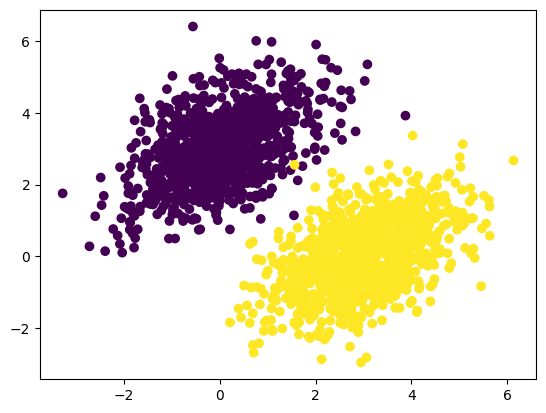

In [30]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [31]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [32]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [33]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [34]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets) #MSE loos
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

선택하신 코드는 TensorFlow를 사용하여 커스텀 훈련 루프의 한 단계(1 epoch 또는 1 batch의 업데이트)를 정의한 training_step 함수입니다. 선형 분류 모델의 가중치 $W$$W$와 편향 $b$$b$를 학습 데이터에 맞게 업데이트하는 역할을 합니다.

각 부분의 세부 설명은 다음과 같습니다:

1. learning_rate = 0.1:

모델이 학습할 때 가중치를 얼마나 큰 폭으로 업데이트할지 결정하는 하이퍼파라미터(학습률)를 0.1로 설정합니다.

2. @tf.function(jit_compile=True):

TensorFlow의 데코레이터로, 파이썬 함수를 정적 그래프로 컴파일하여 실행 속도를 높입니다. jit_compile=True 옵션은 XLA(Accelerated Linear Algebra) 컴파일러를 활성화하여 연속된 연산들을 병합하고 하드웨어에 최적화해 성능을 더욱 극대화합니다.

3. with tf.GradientTape() as tape::

이 블록 안에서 일어나는 연산을 기록하여, 가중치들에 대한 손실 함수의 미분값(그레이디언트)을 계산할 수 있게 준비합니다.
predictions = model(inputs, W, b): 현재의 $W$$W$와 $b$$b$로 예측값(모델 출력)을 계산합니다.
loss = mean_squared_error(predictions, targets): 예측값과 실제 정답(targets) 사이의 평균 제곱 오차(MSE)를 구하여 손실(Loss)을 측정합니다.

4. grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b]):

기록된 연산 그래프를 바탕으로, 계산된 손실(loss)을 가중치 W와 편향 b로 각각 편미분한 값(그레이디언트)을 얻습니다.

5. W.assign_sub(...) 및 b.assign_sub(...):

경사하강법(Gradient Descent) 공식($ heta = heta - ext{learning_rate} imes ext{gradient}$$ heta = heta - ext{learning_rate} imes ext{gradient}$)에 따라 변수의 값을 업데이트합니다.
assign_sub는 TensorFlow 변수에서 입력값을 빼주는 연산으로, 계산된 미분값에 학습률(0.1)을 곱한 만큼 기존 가중치와 편향에서 빼주어 손실이 줄어드는 방향으로 모델을 학습시킵니다.

6. return loss:

현재 단계의 손실 값을 반환하여 훈련 진행 상황을 모니터링할 수 있게 합니다.

In [29]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 5.2791
Loss at step 1: 0.7570
Loss at step 2: 0.2311
Loss at step 3: 0.1568
Loss at step 4: 0.1386
Loss at step 5: 0.1281
Loss at step 6: 0.1193
Loss at step 7: 0.1113
Loss at step 8: 0.1040
Loss at step 9: 0.0974
Loss at step 10: 0.0913
Loss at step 11: 0.0857
Loss at step 12: 0.0806
Loss at step 13: 0.0760
Loss at step 14: 0.0717
Loss at step 15: 0.0679
Loss at step 16: 0.0643
Loss at step 17: 0.0611
Loss at step 18: 0.0581
Loss at step 19: 0.0554
Loss at step 20: 0.0529
Loss at step 21: 0.0507
Loss at step 22: 0.0486
Loss at step 23: 0.0467
Loss at step 24: 0.0450
Loss at step 25: 0.0434
Loss at step 26: 0.0420
Loss at step 27: 0.0407
Loss at step 28: 0.0395
Loss at step 29: 0.0384
Loss at step 30: 0.0374
Loss at step 31: 0.0364
Loss at step 32: 0.0356
Loss at step 33: 0.0348
Loss at step 34: 0.0341
Loss at step 35: 0.0335
Loss at step 36: 0.0329
Loss at step 37: 0.0324
Loss at step 38: 0.0319
Loss at step 39: 0.0314


선택하신 코드는 정의된 모델을 데이터에 맞게 40회 반복하여 학습(훈련)시키는 루프입니다.

각 부분의 세부 설명은 다음과 같습니다:

1. for step in range(40)::

아래의 코드 블록을 40번 반복 실행합니다. 변수 step은 0부터 39까지 순차적으로 증가합니다.

2. loss = training_step(inputs, targets, W, b):

이전에 정의한 training_step 함수를 호출합니다.
이 함수는 현재의 가중치(W)와 편향(b)을 사용하여 예측을 수행하고, 실제 정답(targets)과의 평균 제곱 오차(Loss)를 계산한 후, 경사하강법을 통해 W와 b를 한 단계 업데이트(학습)합니다.
함수가 계산하고 반환한 해당 스텝의 손실(Loss) 값이 loss 변수에 저장됩니다.

3. print(f"Loss at step {step}: {loss:.4f}"):

현재 학습 단계(step)와 계산된 손실 값(loss)을 소수점 아래 4자리까지 포맷팅하여 화면에 출력합니다.
학습이 제대로 진행된다면 반복될수록 손실 값이 점차 작아지는 것을 확인할 수 있습니다.

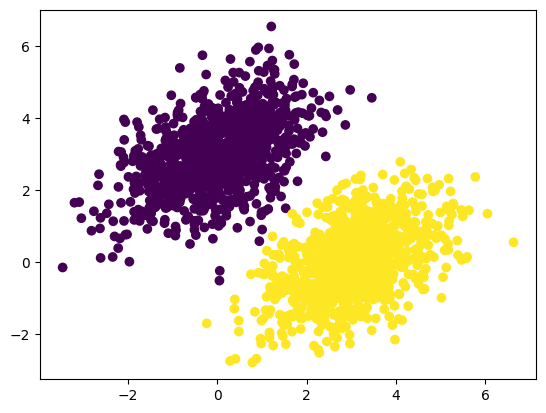

In [30]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

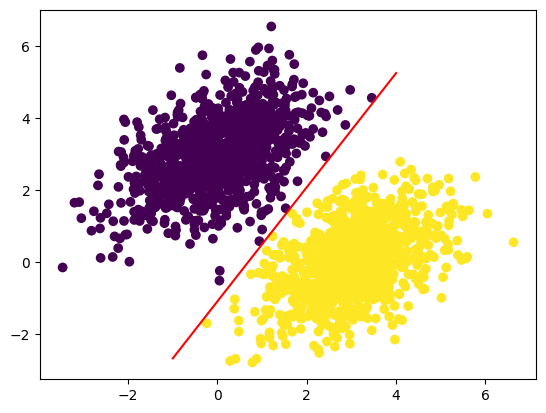

In [31]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#### What makes the TensorFlow approach unique

### Introduction to PyTorch

#### First steps with PyTorch

##### Tensors and parameters in PyTorch

###### Constant tensors

In [35]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [36]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [37]:
torch.tensor([1, 2, 3], dtype=torch.float32)

tensor([1., 2., 3.])

###### Random tensors

In [38]:
torch.normal(
mean=torch.zeros(size=(3, 1)),
std=torch.ones(size=(3, 1)))

tensor([[ 0.3313],
        [ 0.7828],
        [-2.4674]])

In [39]:
torch.rand(3, 1)

tensor([[0.4728],
        [0.8201],
        [0.3617]])

###### Tensor assignment and the Parameter class

In [40]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

In [41]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

##### Tensor operations: Doing math in PyTorch

In [42]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

선택하신 코드는 PyTorch를 사용하여 기초적인 텐서 생성 및 수학적 연산을 수행하는 예제입니다.

각 행의 연산에 대한 설명은 다음과 같습니다:

1. a = torch.ones((2, 2)):

$2 \times 2$ 크기의 모든 원소가 1.0인 2차원 텐서(행렬)를 생성합니다.

2. b = torch.square(a):

텐서 a에 있는 모든 원소를 각각 제곱($x^2$)합니다. 원소들이 모두 1이므로 결과도 동일하게 1로 구성된 텐서가 됩니다.

3. c = torch.sqrt(a):

텐서 a에 있는 모든 원소에 제곱근($\sqrt{x}$)을 적용합니다. 마찬가지로 1로 구성된 텐서가 생성됩니다.

4. d = b + c:

두 텐서 b와 c를 요소별(element-wise)로 더합니다. 결과 텐서 d는 모든 원소가 2.0인 $2\times 2$ 크기의 텐서가 됩니다.

5. e = torch.matmul(a, b):

두 텐서 a와 b 사이의 **행렬 곱(matrix multiplication)**을 수행합니다.

6. f = torch.cat((a, b), dim=0):

두 텐서 a와 b를 첫 번째 차원(dim=0, 세로 방향)을 기준으로 이어 붙입니다. 기존 $2 \times 2$$2 \times 2$ 크기 텐서 두 개가 위아래로 합쳐져 $4 \times 2$$4 \times 2$ 크기의 텐서 f가 생성됩니다.

In [43]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### Computing gradients with PyTorch

In [44]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward() #계산할 때 넣는 것
gradient = input_var.grad
gradient

tensor(6.)

In [45]:
result = torch.square(input_var)
result.backward()
input_var.grad

tensor(12.)

In [46]:
input_var.grad = None #계산한 뒤에 빼먹지 말기!

#### An end-to-end example: A linear classifier in pure PyTorch

In [47]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [48]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [49]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [50]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None
    b.grad = None
    return loss

##### Packaging state and computation with the Module class

In [51]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [52]:
model = LinearModel()

In [53]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [54]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [55]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

##### Making PyTorch modules fast using compilation

In [56]:
compiled_model = torch.compile(model)

In [57]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### What makes the PyTorch approach unique

### Introduction to JAX

#### First steps with JAX

#### Tensors in JAX

In [ ]:
from jax import numpy as jnp
jnp.ones(shape=(2, 1))

In [ ]:
jnp.zeros(shape=(2, 1))

In [ ]:
jnp.array([1, 2, 3], dtype="float32")

#### Random number generation in JAX

In [ ]:
np.random.normal(size=(3,))

In [ ]:
np.random.normal(size=(3,))

In [ ]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
y = apply_noise(x, seed)
seed += 1
z = apply_noise(x, seed)

In [ ]:
import jax

seed_key = jax.random.key(1337)

In [ ]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))

In [ ]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

In [ ]:
jax.random.normal(seed_key, shape=(3,))

In [ ]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

In [ ]:
new_seed_key = jax.random.split(seed_key, num=1)[0]
jax.random.normal(new_seed_key, shape=(3,))

##### Tensor assignment

In [ ]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)

##### Tensor operations: Doing math in JAX

In [ ]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [ ]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### Computing gradients with JAX

In [ ]:
def compute_loss(input_var):
    return jnp.square(input_var)

In [ ]:
grad_fn = jax.grad(compute_loss)

In [ ]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)

##### JAX gradient-computation best practices << 생략하심 안 중요한가?..

###### Returning the loss value

In [ ]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)

###### Getting gradients for a complex function

###### Returning auxiliary outputs

##### Making JAX functions fast with @jax.jit

In [ ]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure JAX

In [ ]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [ ]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

In [ ]:
grad_fn = jax.value_and_grad(compute_loss)

In [ ]:
learning_rate = 0.1

@jax.jit
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate
    return loss, W, b

In [ ]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

#### What makes the JAX approach unique

### Introduction to Keras

#### First steps with Keras

##### Picking a backend framework

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

#### Layers: The building blocks of deep learning

##### The base `Layer` class in Keras

In [58]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [59]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


##### Automatic shape inference: Building layers on the fly

In [60]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [61]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [62]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

#### From layers to models

#### The "compile" step: Configuring the learning process

In [63]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

In [64]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

#### Picking a loss function

#### Understanding the fit method

In [ ]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

In [ ]:
history.history

#### Monitoring loss and metrics on validation data

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

#### Inference: Using a model after training

In [ ]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])